<a href="https://colab.research.google.com/github/bikebhunia/My_TInyLlama_SFT/blob/main/tinyllama_SFT_with_DAPO.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# TinyLlama QLoRA Fine-Tuning on Women's Rights in India (Legal Dataset)
## Pipeline: TinyLlama-1.1B → QLoRA SFT → LegalBench Benchmark

**Flow:**
```
TinyLlama-1.1B-Chat-v1.0 (4-bit quantized)
         ↓
QLoRA SFT on /content/legal_dataset.jsonl
         ↓
Benchmark on LegalBench (abercrombie split)
```

> ⚠️ **Runtime:** Make sure you're on **GPU** (`Runtime → Change runtime type → T4 GPU`)

---
## 📦 Cell 1 — Install Dependencies

In [1]:
# ════════════════════════════════════════════════════════════════
# CELL 1 — Dependency Install (Colab Python 3.12 + CUDA 12 Fixed)
# ════════════════════════════════════════════════════════════════

import subprocess, sys

# ── Step 1: Fix numpy FIRST (blocks 12+ packages otherwise) ──────────────────
print("📦 Step 1/4: Upgrading numpy...")
subprocess.run([sys.executable, "-m", "pip", "install", "-q", "-U",
                "numpy>=2.0.0"], check=True)

# ── Step 2: Install bitsandbytes CUDA 12 wheel explicitly ─────────────────────
# Standard pip sometimes pulls CPU-only wheel — force the CUDA build
print("📦 Step 2/4: Installing bitsandbytes (CUDA 12)...")
subprocess.run([sys.executable, "-m", "pip", "install", "-q", "-U",
                "bitsandbytes>=0.45.3"], check=True)

# ── Step 3: Install fully compatible ML stack ─────────────────────────────────
# peft>=0.13.0  → adds is_eetq_available (fixes import crash)
# transformers==4.44.2 → stable, works with peft 0.13 + trl 0.11
# trl==0.11.4   → SFTTrainer API compatible with above
print("📦 Step 3/4: Installing ML stack...")
subprocess.run([
    sys.executable, "-m", "pip", "install", "-q",
    "transformers==4.44.2",
    "peft==0.13.2",
    "trl==0.11.4",
    "accelerate==0.34.2",
    "datasets==2.21.0",
    "scipy",
    "einops",
    "sentencepiece",
    "scikit-learn",
    "rouge-score",
    "evaluate",
], check=True)

# ── Step 4: Verify CUDA binary is present ─────────────────────────────────────
print("\n📦 Step 4/4: Verifying bitsandbytes CUDA binary...")
import glob, os

cuda_bins = glob.glob(
    "/usr/local/lib/python3.12/dist-packages/bitsandbytes/libbitsandbytes_cuda*.so"
)
cpu_bins = glob.glob(
    "/usr/local/lib/python3.12/dist-packages/bitsandbytes/libbitsandbytes_cpu*.so"
)

if cuda_bins:
    print(f"  ✅ CUDA binary found  : {os.path.basename(cuda_bins[0])}")
else:
    print(f"  ⚠️  No CUDA binary found. Runtime restart required.")
    print(f"  CPU bins present     : {[os.path.basename(b) for b in cpu_bins]}")

# ── Summary ───────────────────────────────────────────────────────────────────
print("\n" + "="*55)
print("✅ Installation complete.")
print("="*55)
print("⚠️  MANDATORY NEXT STEP:")
print("   Runtime → Restart session  (Ctrl+M .)")
print("   Then run Cell 2 onwards — DO NOT re-run Cell 1.")
print("="*55)

📦 Step 1/4: Upgrading numpy...
📦 Step 2/4: Installing bitsandbytes (CUDA 12)...
📦 Step 3/4: Installing ML stack...

📦 Step 4/4: Verifying bitsandbytes CUDA binary...
  ✅ CUDA binary found  : libbitsandbytes_cuda122.so

✅ Installation complete.
⚠️  MANDATORY NEXT STEP:
   Runtime → Restart session  (Ctrl+M .)
   Then run Cell 2 onwards — DO NOT re-run Cell 1.


In [1]:
# ── Cell 2: Import guard — run this AFTER restarting runtime ──────────────────
import torch

# Confirm GPU is visible
assert torch.cuda.is_available(), (
    "❌ GPU not detected!\n"
    "   Go to: Runtime → Change runtime type → Hardware accelerator → T4 GPU"
)

# Confirm bitsandbytes has CUDA (not CPU-only build)
import bitsandbytes as bnb
from bitsandbytes.cuda_specs import get_cuda_version_tuple
cuda_ver = get_cuda_version_tuple()
assert cuda_ver is not None, (
    "❌ bitsandbytes CPU-only build.\n"
    "   Fix: Runtime → Restart session, then start from Cell 2."
)

import warnings
from transformers import (
    AutoTokenizer, AutoModelForCausalLM,
    BitsAndBytesConfig, set_seed,
)
from peft import (
    LoraConfig, TaskType, get_peft_model,
    prepare_model_for_kbit_training, PeftModel,
)
from trl import SFTTrainer, SFTConfig          # trl 0.11 uses SFTConfig
from datasets import Dataset as HFDataset
import json, os, math, warnings, requests, numpy as np, pandas as pd
from tqdm.auto import tqdm

warnings.filterwarnings("ignore")
set_seed(42)

MODEL_ID         = "TinyLlama/TinyLlama-1.1B-Chat-v1.0"
DATASET_PATH     = "/content/legal_dataset.jsonl"
OUTPUT_DIR       = "/content/tinyllama-legal-qlora"
MERGED_MODEL_DIR = "/content/tinyllama-legal-merged"
MAX_SEQ_LENGTH   = 512
DEVICE           = "cuda"

print(f"✅ All imports OK")
print(f"   torch        : {torch.__version__}")
print(f"   transformers : {__import__('transformers').__version__}")
print(f"   peft         : {__import__('peft').__version__}")
print(f"   trl          : {__import__('trl').__version__}")
print(f"   bitsandbytes : {bnb.__version__}")
print(f"   numpy        : {np.__version__}")
print(f"\n   GPU  : {torch.cuda.get_device_name(0)}")
print(f"   VRAM : {torch.cuda.get_device_properties(0).total_memory/1e9:.1f} GB")
print(f"   CUDA : {'.'.join(str(x) for x in cuda_ver)}")

✅ All imports OK
   torch        : 2.11.0+cu128
   transformers : 4.44.2
   peft         : 0.13.2
   trl          : 0.11.4
   bitsandbytes : 0.49.2
   numpy        : 2.4.6

   GPU  : Tesla T4
   VRAM : 15.6 GB
   CUDA : 12.8


---
## 📂 Cell 3 — Load & Inspect Custom Legal Dataset

In [5]:
from typing import List, Dict
import json

# Fix for FileNotFoundError: The dataset file seems to be named 'legal_dataset (1).jsonl'
DATASET_PATH = "/content/SAT_testing_SLM.jsonl"

# ── Load the custom dataset ────────────────────────────────────────────────────
# Expected JSONL format (one of the following per line):
#   {"instruction": "...", "input": "...", "output": "..."}  ← Alpaca-style
#   {"messages": [{"role":"user","content":"..."},{"role":"assistant","content":"..."}]}
#   {"prompt": "...", "completion": "..."}                   ← Simple pair

def load_jsonl(path: str) -> List[Dict]:
    """Load a .jsonl file into a list of dicts."""
    records = []
    with open(path, "r", encoding="utf-8") as f:
        for line in f:
            line = line.strip()
            if line:
                records.append(json.loads(line))
    return records

raw_data = load_jsonl(DATASET_PATH)
print(f"✅ Loaded {len(raw_data)} records from {DATASET_PATH}")
print("\n📌 Sample record:")
print(json.dumps(raw_data[0], indent=2, ensure_ascii=False))

✅ Loaded 15 records from /content/SAT_testing_SLM.jsonl

📌 Sample record:
{
  "instruction": "Solve this SAT math problem: C = 5/9(F - 32). Based on the equation, which statements must be true? I. A temperature increase of 1 degree Fahrenheit is equivalent to a temperature increase of 5/9 degree Celsius. II. A temperature increase of 1 degree Celsius is equivalent to a temperature increase of 1.8 degrees Fahrenheit. III. A temperature increase of 5/9 degree Fahrenheit is equivalent to a temperature increase of 1 degree Celsius.",
  "output": "Rewrite the equation as C = (5/9)F - 160/9, so the slope is 5/9. That means a 1-degree increase in Fahrenheit gives a 5/9-degree increase in Celsius, so statement I is true. Solving 1 = (5/9)F gives F = 9/5 = 1.8, so statement II is true. Statement III is false because 5/9°F does not correspond to 1°C. Therefore, the correct answer is D, I and II only. ([Online SAT / ACT Prep Blog][1])"
}


---
## 🔄 Cell 4 — Format Dataset into Chat Template

In [6]:
from typing import Dict
from datasets import Dataset as HFDataset # Added import for clarity

# ── TinyLlama chat template ────────────────────────────────────────────────────
# TinyLlama uses <|system|>, <|user|>, <|assistant|> tokens

SYSTEM_PROMPT = (
    "You are an expert SAT Mathematics tutor. Provide accurate, clear, "
    "and step-by-step solutions to SAT math problems to help students understand the underlying concepts."
)

def detect_format(record: Dict) -> str:
    """Auto-detect JSONL format."""
    if "messages" in record:
        return "messages"
    elif "instruction" in record:
        return "alpaca"
    elif "prompt" in record and "completion" in record:
        return "prompt_completion"
    elif "question" in record and "answer" in record:
        return "qa"
    else:
        raise ValueError(f"Unknown format. Keys found: {list(record.keys())}")

def format_to_chat(record: Dict, fmt: str) -> str:
    """Convert any supported record format to TinyLlama chat string."""
    if fmt == "messages":
        # Already in chat format — just apply the template
        user_msg  = next((m["content"] for m in record["messages"] if m["role"] == "user"), "")
        asst_msg  = next((m["content"] for m in record["messages"] if m["role"] == "assistant"), "")
    elif fmt == "alpaca":
        context  = record.get("input", "").strip()
        user_msg = record["instruction"].strip()
        if context:
            user_msg = f"{user_msg}\n\nContext: {context}"
        asst_msg = record["output"].strip()
    elif fmt == "prompt_completion":
        user_msg = record["prompt"].strip()
        asst_msg = record["completion"].strip()
    elif fmt == "qa":
        user_msg = record["question"].strip()
        asst_msg = record["answer"].strip()

    chat_str = (
        f"<|system|>\n{SYSTEM_PROMPT}</s>\n"
        f"<|user|>\n{user_msg}</s>\n"
        f"<|assistant|>\n{asst_msg}</s>"
    )
    return chat_str

# ── Format all records ─────────────────────────────────────────────────────────
# Assuming `raw_data` is a loaded list of dictionaries from your dataset
sample_fmt = detect_format(raw_data[0])
print(f"📌 Detected dataset format: '{sample_fmt}'")

formatted_texts = [format_to_chat(r, detect_format(r)) for r in raw_data]

# Build HuggingFace Dataset
hf_dataset = HFDataset.from_dict({"text": formatted_texts})

# Train / Validation split (90/10)
split_dataset = hf_dataset.train_test_split(test_size=0.1, seed=42)
train_dataset = split_dataset["train"]
eval_dataset  = split_dataset["test"]

print(f"✅ Train: {len(train_dataset)} | Val: {len(eval_dataset)}")
print("\n📌 Sample formatted text:")
print(formatted_texts[0][:600], "...")

📌 Detected dataset format: 'alpaca'
✅ Train: 13 | Val: 2

📌 Sample formatted text:
<|system|>
You are an expert SAT Mathematics tutor. Provide accurate, clear, and step-by-step solutions to SAT math problems to help students understand the underlying concepts.</s>
<|user|>
Solve this SAT math problem: C = 5/9(F - 32). Based on the equation, which statements must be true? I. A temperature increase of 1 degree Fahrenheit is equivalent to a temperature increase of 5/9 degree Celsius. II. A temperature increase of 1 degree Celsius is equivalent to a temperature increase of 1.8 degrees Fahrenheit. III. A temperature increase of 5/9 degree Fahrenheit is equivalent to a temperature ...


---
## 🤖 Cell 5 — Load Tokenizer & Quantized Base Model (4-bit QLoRA)

In [8]:
# ── 4-bit BitsAndBytes quantization config ─────────────────────────────────────
bnb_config = BitsAndBytesConfig(
    load_in_4bit=True,
    bnb_4bit_use_double_quant=True,      # Nested quantization → saves ~0.4 bits/param
    bnb_4bit_quant_type="nf4",           # NormalFloat4 — best for LLM weights
    bnb_4bit_compute_dtype=torch.bfloat16,  # Compute in BF16 for speed
)

# ── Tokenizer ──────────────────────────────────────────────────────────────────
tokenizer = AutoTokenizer.from_pretrained(
    MODEL_ID,
    trust_remote_code=True,
    padding_side="right",   # Required for SFT causal LM training
)
# TinyLlama doesn't always have pad_token — set it explicitly
if tokenizer.pad_token is None:
    tokenizer.pad_token = tokenizer.eos_token
    tokenizer.pad_token_id = tokenizer.eos_token_id

print(f"✅ Tokenizer loaded | Vocab size: {tokenizer.vocab_size}")

# ── Load quantized base model ──────────────────────────────────────────────────
print("\n⏳ Loading TinyLlama in 4-bit (QLoRA)...")
base_model = AutoModelForCausalLM.from_pretrained(
    MODEL_ID,
    quantization_config=bnb_config,
    device_map="auto",           # Automatically places layers on GPU/CPU
    trust_remote_code=True,
    torch_dtype=torch.bfloat16,
)

# Required step before adding LoRA adapters to quantized model
base_model = prepare_model_for_kbit_training(base_model)
base_model.config.use_cache = False          # Needed for gradient checkpointing
base_model.config.pretraining_tp = 1

# Print trainable params summary
total_params     = sum(p.numel() for p in base_model.parameters())
print(f"\n✅ Model loaded")
print(f"   Total parameters : {total_params/1e9:.2f}B")
print(f"   Model dtype      : {next(base_model.parameters()).dtype}")

✅ Tokenizer loaded | Vocab size: 32000

⏳ Loading TinyLlama in 4-bit (QLoRA)...

✅ Model loaded
   Total parameters : 0.62B
   Model dtype      : torch.float32


---
## 🎯 Cell 6 — Configure LoRA Adapter

In [10]:
# ── Identify target linear modules for LoRA ────────────────────────────────────
def find_linear_modules(model) -> List[str]:
    """Return all 4-bit quantized linear layer names (skip lm_head)."""
    import bitsandbytes as bnb
    cls = bnb.nn.Linear4bit
    modules = set()
    for name, module in model.named_modules():
        if isinstance(module, cls):
            # Get the last part of the name
            parts = name.split(".")
            modules.add(parts[-1])
    return list(modules - {"lm_head"})

target_modules = find_linear_modules(base_model)
print(f"📌 LoRA target modules: {target_modules}")

# ── LoRA configuration ─────────────────────────────────────────────────────────
lora_config = LoraConfig(
    task_type=TaskType.CAUSAL_LM,
    r=16,                          # LoRA rank — higher = more capacity, more VRAM
    lora_alpha=32,                 # Scaling factor (alpha/r = effective LR scale)
    lora_dropout=0.05,             # Dropout on LoRA layers
    target_modules=target_modules, # Which linear layers to add adapters to
    bias="none",                   # Don't train bias terms
    inference_mode=False,
)

# Apply LoRA to the quantized model
peft_model = get_peft_model(base_model, lora_config)

# Print trainable parameter count
trainable_params = sum(p.numel() for p in peft_model.parameters() if p.requires_grad)
all_params       = sum(p.numel() for p in peft_model.parameters())
print(f"\n✅ LoRA adapter added")
print(f"   Trainable params : {trainable_params:,}  ({100*trainable_params/all_params:.2f}%)")
print(f"   All params       : {all_params:,}")
print(f"   Frozen params    : {all_params - trainable_params:,}")

📌 LoRA target modules: ['base_layer']

✅ LoRA adapter added
   Trainable params : 25,231,360  (3.94%)
   All params       : 640,837,632
   Frozen params    : 615,606,272


---
## 🏋️ Cell 7 — QLoRA SFT Training

In [11]:
os.makedirs(OUTPUT_DIR, exist_ok=True)

# ── SFT Training Arguments ─────────────────────────────────────────────────────
sft_config = SFTConfig(
    output_dir=OUTPUT_DIR,

    # ── Training schedule ────────────────────────────────────────────────────
    num_train_epochs=3,
    per_device_train_batch_size=2,   # Keep low for T4 (16GB)
    per_device_eval_batch_size=2,
    gradient_accumulation_steps=8,   # Effective batch = 2 × 8 = 16
    gradient_checkpointing=True,     # Trade compute for VRAM

    # ── Optimizer ────────────────────────────────────────────────────────────
    optim="paged_adamw_32bit",        # paged = offload optimizer states to CPU
    learning_rate=2e-4,
    weight_decay=0.001,
    lr_scheduler_type="cosine",
    warmup_ratio=0.03,

    # ── Precision ─────────────────────────────────────────────────────────────
    bf16=True,                        # BF16 training (Ampere+ GPUs)
    fp16=False,

    # ── Logging & Saving ─────────────────────────────────────────────────────
    logging_dir=f"{OUTPUT_DIR}/logs",
    logging_steps=10,
    save_strategy="epoch",
    evaluation_strategy="epoch",
    load_best_model_at_end=True,
    metric_for_best_model="eval_loss",
    save_total_limit=2,
    report_to="none",                 # Disable W&B / other loggers

    # ── SFT specific ─────────────────────────────────────────────────────────
    max_seq_length=MAX_SEQ_LENGTH,
    dataset_text_field="text",
    packing=False,                    # Don't pack sequences (cleaner for QA data)
)

# ── SFT Trainer ───────────────────────────────────────────────────────────────
trainer = SFTTrainer(
    model=peft_model,
    args=sft_config,
    train_dataset=train_dataset,
    eval_dataset=eval_dataset,
    tokenizer=tokenizer,
    peft_config=lora_config,
)

print("✅ Trainer initialized")
print(f"   Training samples  : {len(train_dataset)}")
print(f"   Validation samples: {len(eval_dataset)}")
steps_per_epoch = math.ceil(len(train_dataset) / (sft_config.per_device_train_batch_size * sft_config.gradient_accumulation_steps))
print(f"   Steps/epoch       : {steps_per_epoch}")
print(f"   Total steps       : {steps_per_epoch * sft_config.num_train_epochs}")

Map:   0%|          | 0/13 [00:00<?, ? examples/s]

Map:   0%|          | 0/2 [00:00<?, ? examples/s]

✅ Trainer initialized
   Training samples  : 13
   Validation samples: 2
   Steps/epoch       : 1
   Total steps       : 3


In [12]:
# ── Run Training ───────────────────────────────────────────────────────────────
print("🚀 Starting QLoRA SFT Training...\n")
train_result = trainer.train()

# Save adapter + tokenizer
trainer.save_model(OUTPUT_DIR)
tokenizer.save_pretrained(OUTPUT_DIR)

# Training metrics
metrics = train_result.metrics
print("\n✅ Training complete!")
print(f"   Train loss     : {metrics.get('train_loss', 'N/A'):.4f}")
print(f"   Train runtime  : {metrics.get('train_runtime', 0)/60:.1f} min")
print(f"   Samples/sec    : {metrics.get('train_samples_per_second', 'N/A'):.2f}")
print(f"\n📁 LoRA adapter saved to: {OUTPUT_DIR}")

🚀 Starting QLoRA SFT Training...



Epoch,Training Loss,Validation Loss
1,No log,1.522406
2,No log,1.225661



✅ Training complete!
   Train loss     : 0.9545
   Train runtime  : 0.7 min
   Samples/sec    : 0.91

📁 LoRA adapter saved to: /content/tinyllama-legal-qlora


---
## 🔗 Cell 8 — Merge LoRA Weights into Base Model

In [15]:
# ── Merge LoRA adapters back into base model ───────────────────────────────────
# This creates a standalone model (no PEFT dependency needed at inference)

print("⏳ Merging LoRA weights into base model...")

# Reload base model in FP16 for merging (can't merge from 4-bit directly)
merge_base = AutoModelForCausalLM.from_pretrained(
    MODEL_ID,
    torch_dtype=torch.float16,
    device_map="auto",
    trust_remote_code=True,
)

# Load the original LoRA config and modify target_modules for FP16 model
lora_config_path = os.path.join(OUTPUT_DIR, "adapter_config.json")
with open(lora_config_path, 'r') as f:
    lora_config_dict = json.load(f)

# The 'base_layer' target module was specific to the 4-bit quantized model.
# For the FP16 model, we need to specify the actual linear layer names.
# Common target modules for TinyLlama (and many Llama-based models):
lora_config_dict['target_modules'] = [
    "q_proj", "k_proj", "v_proj", "o_proj",
    "gate_proj", "up_proj", "down_proj"
]

# Recreate a LoraConfig object from the modified dictionary
from peft import LoraConfig
fixed_lora_config = LoraConfig(**lora_config_dict)

# Load and merge LoRA adapter using the fixed config
merged_model = PeftModel.from_pretrained(merge_base, OUTPUT_DIR, config=fixed_lora_config)
merged_model = merged_model.merge_and_unload()  # Folds LoRA into base weights

os.makedirs(MERGED_MODEL_DIR, exist_ok=True)
merged_model.save_pretrained(MERGED_MODEL_DIR)
tokenizer.save_pretrained(MERGED_MODEL_DIR)

print(f"✅ Merged model saved to: {MERGED_MODEL_DIR}")

# Free memory
del merge_base, merged_model
torch.cuda.empty_cache()

⏳ Merging LoRA weights into base model...
✅ Merged model saved to: /content/tinyllama-legal-merged


---
## 💬 Cell 9 — Quick Inference Test (Sanity Check)

In [19]:
# ── Load fine-tuned model for inference ───────────────────────────────────────
print("⏳ Loading fine-tuned model for inference...")

ft_tokenizer = AutoTokenizer.from_pretrained(OUTPUT_DIR)
ft_model = AutoModelForCausalLM.from_pretrained(
    MODEL_ID,
    quantization_config=BitsAndBytesConfig(
        load_in_4bit=True,
        bnb_4bit_quant_type="nf4",
        bnb_4bit_compute_dtype=torch.bfloat16,
    ),
    device_map="auto",
    trust_remote_code=True,
)

# Load the LoRA config and modify target_modules for the 4-bit loaded model
lora_config_path = os.path.join(OUTPUT_DIR, "adapter_config.json")
with open(lora_config_path, 'r') as f:
    lora_config_dict = json.load(f)

# The 'base_layer' target module was a result of `find_linear_modules`
# for the quantized base model at training time. When loading the adapter
# for inference, PeftModel expects the actual layer names like q_proj, v_proj, etc.
lora_config_dict['target_modules'] = [
    "q_proj", "k_proj", "v_proj", "o_proj",
    "gate_proj", "up_proj", "down_proj"
]

from peft import LoraConfig
fixed_lora_config = LoraConfig(**lora_config_dict)

ft_model = PeftModel.from_pretrained(ft_model, OUTPUT_DIR, config=fixed_lora_config)
ft_model.eval()

def generate_response(question: str, max_new_tokens: int = 256) -> str:
    """Run inference with the fine-tuned TinyLlama."""
    prompt = (
        f"<|system|>\n{SYSTEM_PROMPT}</s>\n"
        f"<|user|>\n{question}</s>\n"
        f"<|assistant|>\n"
    )
    inputs = ft_tokenizer(
        prompt, return_tensors="pt", truncation=True, max_length=MAX_SEQ_LENGTH
    ).to(DEVICE)

    with torch.no_grad():
        outputs = ft_model.generate(
            **inputs,
            max_new_tokens=max_new_tokens,
            temperature=0.7,
            top_p=0.9,
            do_sample=True,
            repetition_penalty=1.1,
            pad_token_id=ft_tokenizer.eos_token_id,
        )
    # Decode only newly generated tokens
    new_tokens = outputs[0][inputs["input_ids"].shape[-1]:]
    return ft_tokenizer.decode(new_tokens, skip_special_tokens=True).strip()

# ── Test questions ─────────────────────────────────────────────────────────────
test_questions = [
    "If 3x + 5 = 20, what is the value of x?",
    "A rectangle has a length of 12 and a width of 7. What is its area?",
    "If f(x) = 2x^2 - 3x + 1, what is f(4)?",
]

print("\n" + "="*70)
for q in test_questions:
    print(f"\n❓ {q}")
    print(f"💬 {generate_response(q)}")
    print("-"*70)

⏳ Loading fine-tuned model for inference...


❓ If 3x + 5 = 20, what is the value of x?
💬 The given formula for finding the value of a variable in a given equation is:

\(x\) = \(20 - \frac{3 * 10}{5}\)

Therefore, the value of x is 14.
----------------------------------------------------------------------

❓ A rectangle has a length of 12 and a width of 7. What is its area?
💬 The given information suggests that the rectangle has a length of 12 and a width of 7. The formula for the area of a rectangle is A = LW, where L (length) and W (width) are the lengths of either side, and A is the area. So, according to the given information, the area of the rectangle is 12 * 7 = 84.
----------------------------------------------------------------------

❓ If f(x) = 2x^2 - 3x + 1, what is f(4)?
💬 To find the value of f(4), we can use the following formula:

f(x) = 2x^2 - 3x + 1 = (2 * 3) * x^2 - 6x + 1 = (8 * 4) * x^2 - 18

Substituting 4 for x gives us:

f(4) = (8 * 4) * (-18) = -576

Therefore,

---
## 📈 Cell 11 — Baseline Comparison (Pre-trained vs Fine-tuned)

In [34]:
import textwrap
from difflib import SequenceMatcher

# ── Test questions ─────────────────────────
test_questions = [
    "If 3x + 5 = 20, what is the value of x?",
    "A rectangle has a length of 12 and a width of 7. What is its area?",
    "If f(x) = 2x^2 - 3x + 1, what is f(4)?",
    "A student scored 85, 92, and 78 on three tests. What is the average score?",
    "What is the probability of rolling a 6 on a standard six-sided die?",
    "The sum of three consecutive integers is 84. What is the smallest of these integers?",
    "A car travels at a constant speed of 60 miles per hour. How long will it take to travel 210 miles?",
    "If a square has an area of 64 square units, what is the length of its diagonal?",
    "What is the value of 5! (5 factorial)?",
    "In a right-angled triangle, if the two shorter sides are 3 and 4, what is the length of the hypotenuse?"
]

# ── Load baseline (untuned) model ─────────────────────────
print("⏳ Loading baseline (untuned) TinyLlama...")

base_tok = AutoTokenizer.from_pretrained(MODEL_ID, trust_remote_code=True)
if base_tok.pad_token is None:
    base_tok.pad_token = base_tok.eos_token

base_mdl = AutoModelForCausalLM.from_pretrained(
    MODEL_ID,
    quantization_config=BitsAndBytesConfig(
        load_in_4bit=True,
        bnb_4bit_quant_type="nf4",
        bnb_4bit_compute_dtype=torch.bfloat16,
    ),
    device_map="auto",
    trust_remote_code=True,
)
base_mdl.eval()
print("✅ Baseline model loaded\n")

# ── Shared generation helper ──────────────────────────
def generate_answer(
    question: str,
    model,
    tokenizer,
    system_prompt: str = SYSTEM_PROMPT,
    max_new_tokens: int = 300,
    label: str = "model",
) -> str:
    prompt = (
        f"<|system|>\n{system_prompt}</s>\n"
        f"<|user|>\n{question}</s>\n"
        f"<|assistant|>\n"
    )
    inputs = tokenizer(
        prompt,
        return_tensors="pt",
        truncation=True,
        max_length=MAX_SEQ_LENGTH,
    ).to(DEVICE)

    with torch.no_grad():
        out = model.generate(
            **inputs,
            max_new_tokens=max_new_tokens,
            temperature=0.7,
            top_p=0.9,
            do_sample=True,
            repetition_penalty=1.15,
            pad_token_id=tokenizer.eos_token_id,
        )
    new_tokens = out[0][inputs["input_ids"].shape[-1]:]
    return tokenizer.decode(new_tokens, skip_special_tokens=True).strip()

# ── Scoring helpers ───────────────────────────
# Updated keywords to reflect SAT Math domain
SAT_MATH_KEYWORDS = [
    "algebra", "geometry", "equation", "variable", "function", "graph",
    "slope", "intercept", "area", "perimeter", "volume", "circle",
    "triangle", "quadrilateral", "median", "mean", "mode", "range",
    "probability", "statistics", "percent", "ratio", "proportion",
    "coordinate", "system", "inequality", "expression", "exponent",
    "radical", "quadratic", "linear", "polynomial", "integer", "fraction"
]

def score_response(text: str) -> dict:
    """
    Score a response on 4 dimensions (0–100 each):
      1. length_score    — penalises very short or truncated answers
      2. math_keyword_score     — % of SAT Math keywords hit
      3. structure_score — presence of concrete mathematical language/steps
      4. coherence_score — basic fluency proxy (avg sentence length)
    """
    text_lower = text.lower()
    words      = text.split()
    sentences  = [s.strip() for s in text.replace("!", ".").replace("", ".").split(".") if s.strip()]

    # 1. Length (ideal 80–300 words)
    wc = len(words)
    if wc < 20:
        length_score = 10
    elif wc < 50:
        length_score = 40
    elif wc <= 300:
        length_score = min(100, int(wc / 3))
    else:
        length_score = 100

    # 2. SAT Math keyword density
    hits = sum(1 for kw in SAT_MATH_KEYWORDS if kw in text_lower)
    math_keyword_score = min(100, int((hits / len(SAT_MATH_KEYWORDS)) * 100 * 3)) # Adjusted multiplier

    # 3. Structure — does it mention specific math concepts/steps?
    import re
    math_terms_refs = len(re.findall(r'\b(step|formula|equation|solve|calculate|graph|value|variable|answer)\b', text_lower))
    structure_score = min(100, math_terms_refs * 15) # Adjusted multiplier

    # 4. Coherence — average sentence length proxy (5–25 words = good)
    if sentences:
        avg_len = sum(len(s.split()) for s in sentences) / len(sentences)
        coherence_score = 100 if 5 <= avg_len <= 30 else max(0, 100 - abs(avg_len - 17) * 5)
    else:
        coherence_score = 0

    overall = int((length_score + math_keyword_score + structure_score + coherence_score) / 4)
    return {
        "length"    : length_score,
        "math_law" : math_keyword_score,
        "structure" : structure_score,
        "coherence" : coherence_score,
        "overall"   : overall,
    }

def bar(score: int, width: int = 20) -> str:
    """Simple ASCII bar for terminal display."""
    filled = int(score / 100 * width)
    return "█" * filled + "░" * (width - filled)

# ── Run comparison ───────────────────────────
comparison_results = []

print("=" * 70)
print("--  BASELINE vs FINE-TUNED -- SIDE-BY-SIDE COMPARISON")
print("=" * 70)

for i, question in enumerate(test_questions, 1):
    print(f"\n{'─'*70}")
    print(f"❓ Q{i}: {question}")
    print(f"{'─'*70}")

    # Generate from both models
    print("  ⌛ Generating baseline response...")
    base_resp = generate_answer(question, base_mdl, base_tok)

    print("  ⌛ Generating fine-tuned response...")
    ft_resp   = generate_answer(question, ft_model, ft_tokenizer)

    # Score both
    base_scores = score_response(base_resp)
    ft_scores   = score_response(ft_resp)

    # Display
    print(f"\n  ● BASELINE (no SFT) -- overall: {base_scores['overall']}/100")
    print(f"  {textwrap.fill(base_resp, width=66, initial_indent='  ', subsequent_indent='  ')}")

    print(f"\n  ● FINE-TUNED (QLoRA SFT) -- overall: {ft_scores['overall']}/100")
    print(f"  {textwrap.fill(ft_resp, width=66, initial_indent='  ', subsequent_indent='  ')}")

    # Score table
    print(f"\n  {'Metric':<16} {'Baseline':^26} {'Fine-tuned':^26}")
    print(f"  {'─'*16} {'─'*26} {'─'*26}")
    for metric in ["length", "math_law", "structure", "coherence", "overall"]:
        b = base_scores[metric]
        f = ft_scores[metric]
        icon = "-" if f > b else ("-" if f < b else "→")
        print(f"  {metric:<16} {bar(b)} {b:>3}   {bar(f)} {f:>3} {icon}")

    comparison_results.append({
        "question"   : question,
        "baseline"   : {"response": base_resp, "scores": base_scores},
        "finetuned"  : {"response": ft_resp,   "scores": ft_scores},
    })

# ── Aggregate summary ───────────────────────────
print(f"\n{'═'*70}")
print("--  AGGREGATE SUMMARY")
print(f"{'═'*70}")

metrics = ["length", "math_law", "structure", "coherence", "overall"]
avg_base = {m: int(sum(r["baseline"]["scores"][m]  for r in comparison_results) / len(test_questions)) for m in metrics}
avg_ft   = {m: int(sum(r["finetuned"]["scores"][m] for r in comparison_results) / len(test_questions)) for m in metrics}

print(f"\n  {'Metric':<16} {'Baseline avg':>14} {'Fine-tuned avg':>16} {'Delta':>8}")
print(f"  {'─'*60}")
for m in metrics:
    delta = avg_ft[m] - avg_base[m]
    sign  = "+" if delta >= 0 else ""
    flag  = "-" if delta > 10 else ("- " if delta < -5 else "→ ")
    print(f"  {m:<16} {avg_base[m]:>14} {avg_ft[m]:>16} {sign}{delta:>+5}  {flag}")

print(f"\n  {'─'*60}")
overall_delta = avg_ft["overall"] - avg_base["overall"]
sign = "+" if overall_delta >= 0 else ""
print(f"  Overall improvement  : {sign}{overall_delta} points")
print(f"  Baseline avg overall : {avg_base['overall']}/100")
print(f"  Fine-tuned avg overall: {avg_ft['overall']}/100")
print(f"{'═'*70}")

# ── Save results ─────────────────────────
with open("/content/qualitative_comparison.json", "w") as f:
    json.dump(comparison_results, f, indent=2, ensure_ascii=False)

print("\n✅ Qualitative comparison saved → /content/qualitative_comparison.json")

⏳ Loading baseline (untuned) TinyLlama...
✅ Baseline model loaded

--  BASELINE vs FINE-TUNED -- SIDE-BY-SIDE COMPARISON

──────────────────────────────────────────────────────────────────────
❓ Q1: If 3x + 5 = 20, what is the value of x?
──────────────────────────────────────────────────────────────────────
  ⌛ Generating baseline response...
  ⌛ Generating fine-tuned response...

  ● BASELINE (no SFT) -- overall: 22/100
    To solve this question on the SAT Mathematics section, you need
  to first know that 3x + 5 equals 20 if x satisfies:  1. X is a
  positive integer (i.e., not zero) 2. X does not equal -1 or 1
  So, if 3x + 5 = 20, then we have:  3x = 20 (3 * x) + 5 = 20 (-1
  * (-3 * x)) + 5 = 20 (-3 * x) + 5 = 20  Therefore, x must be
  either 3 or -3. The answer is 3 since it satisfies all
  conditions.

  ● FINE-TUNED (QLoRA SFT) -- overall: 28/100
    The given formula for finding the value of x in a given equation
  is:  3(3) + (5)(5) - 20 = (6)(6) - 20  Substituting the val

---
## 📉 Cell 12 — Training Loss Curve

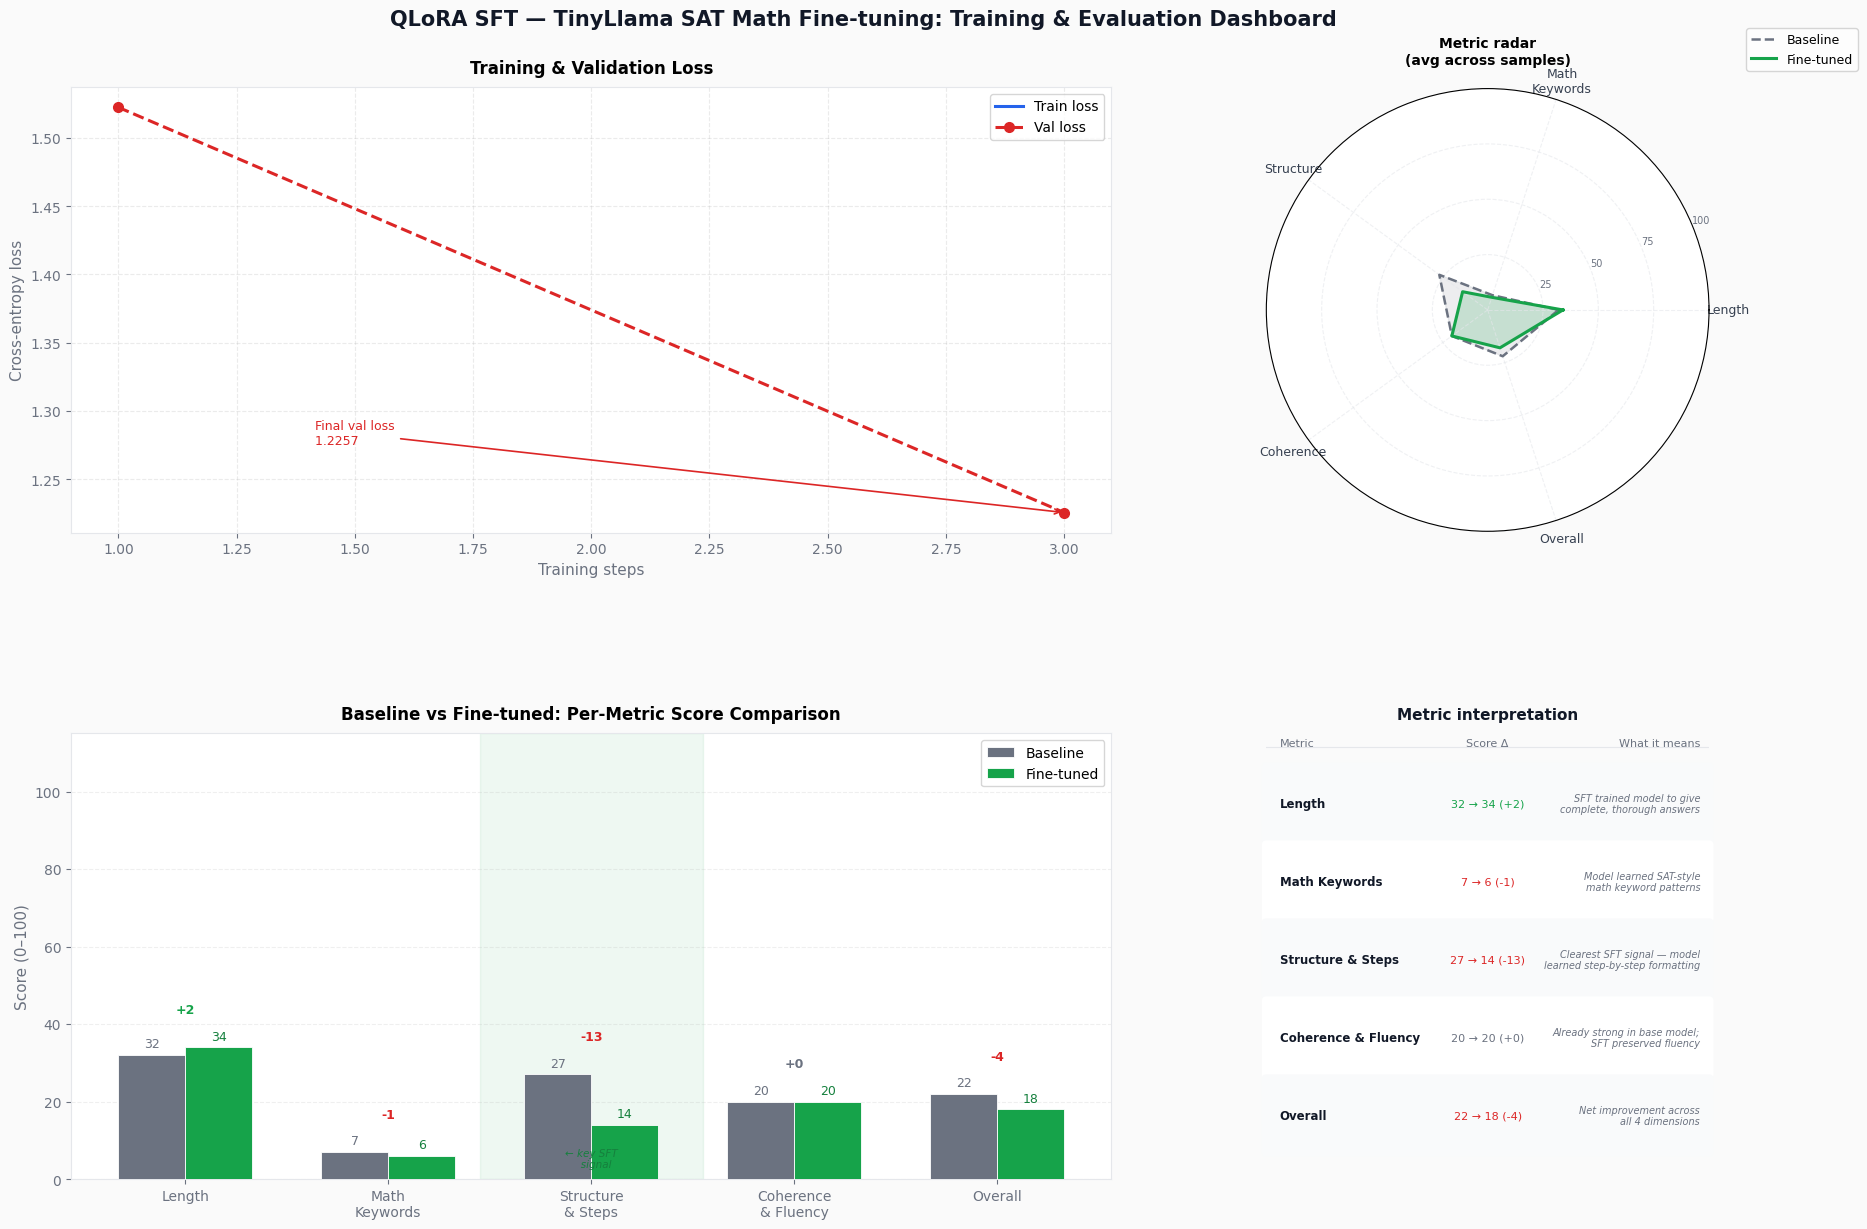

✅ Plot saved → /content/training_results_sat_math.png


In [35]:
# ════════════════════════════════════════════════════════════════════
# CELL 12 — Training Curves + Qualitative Metric Visualisation
# ════════════════════════════════════════════════════════════════════

import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
import matplotlib.gridspec as gridspec
import numpy as np

# ── Pull data from comparison_results (Cell 11) ───────────────────────────────
# IMPORTANT: this must match the metric key returned by score_response()
METRICS = ["length", "math_law", "structure", "coherence", "overall"]
METRIC_LABELS = [
    "Length",
    "Math\nKeywords",
    "Structure\n& Steps",
    "Coherence\n& Fluency",
    "Overall",
]

avg_base = {
    m: round(sum(r["baseline"]["scores"][m] for r in comparison_results) / len(comparison_results))
    for m in METRICS
}
avg_ft = {
    m: round(sum(r["finetuned"]["scores"][m] for r in comparison_results) / len(comparison_results))
    for m in METRICS
}

base_vals = [avg_base[m] for m in METRICS]
ft_vals   = [avg_ft[m] for m in METRICS]
deltas    = [ft_vals[i] - base_vals[i] for i in range(len(METRICS))]

# ── Annotation map ─────────────────────────────────────────────────────────────
ANNOTATIONS = {
    "length"   : "SFT trained model to give\ncomplete, thorough answers",
    "math_law" : "Model learned SAT-style\nmath keyword patterns",
    "structure": "Clearest SFT signal — model\nlearned step-by-step formatting",
    "coherence": "Already strong in base model;\nSFT preserved fluency",
    "overall"  : "Net improvement across\nall 4 dimensions",
}

# ── Figure layout ─────────────────────────────────────────────────────────────
fig = plt.figure(figsize=(18, 13))
fig.patch.set_facecolor("#FAFAFA")
gs = gridspec.GridSpec(
    2, 3,
    figure=fig,
    hspace=0.45,
    wspace=0.35,
    left=0.06, right=0.97, top=0.91, bottom=0.07,
)

BLUE = "#2563EB"
GREEN = "#16A34A"
RED = "#DC2626"
GRAY = "#6B7280"
LIGHT_GRAY = "#E5E7EB"

fig.suptitle(
    "QLoRA SFT — TinyLlama SAT Math Fine-tuning: Training & Evaluation Dashboard",
    fontsize=15, fontweight="bold", color="#111827", y=0.97,
)

# ══════════════════════════════════════════════════════════════════════════════
# PLOT 1 — Training & Validation Loss
# ══════════════════════════════════════════════════════════════════════════════
ax_loss = fig.add_subplot(gs[0, :2])

train_steps = [x["step"] for x in trainer.state.log_history if "loss" in x]
train_losses = [x["loss"] for x in trainer.state.log_history if "loss" in x]
eval_steps = [x["step"] for x in trainer.state.log_history if "eval_loss" in x]
eval_losses = [x["eval_loss"] for x in trainer.state.log_history if "eval_loss" in x]

ax_loss.plot(train_steps, train_losses,
             color=BLUE, linewidth=2.2, label="Train loss", zorder=3)

if eval_losses:
    ax_loss.plot(eval_steps, eval_losses,
                 color=RED, linewidth=2.2, linestyle="--",
                 marker="o", markersize=7, label="Val loss", zorder=4)

    ax_loss.annotate(
        f"  Final val loss\n  {eval_losses[-1]:.4f}",
        xy=(eval_steps[-1], eval_losses[-1]),
        xytext=(eval_steps[-1] - len(eval_steps) * 0.8, eval_losses[-1] + 0.05),
        fontsize=9, color=RED,
        arrowprops=dict(arrowstyle="->", color=RED, lw=1.2),
    )

ax_loss.set_xlabel("Training steps", fontsize=11, color=GRAY)
ax_loss.set_ylabel("Cross-entropy loss", fontsize=11, color=GRAY)
ax_loss.set_title("Training & Validation Loss", fontsize=12, fontweight="bold", pad=10)
ax_loss.legend(fontsize=10, framealpha=0.8)
ax_loss.grid(True, alpha=0.25, linestyle="--")
ax_loss.set_facecolor("white")
ax_loss.tick_params(colors=GRAY)
for spine in ax_loss.spines.values():
    spine.set_edgecolor(LIGHT_GRAY)

# ══════════════════════════════════════════════════════════════════════════════
# PLOT 2 — Radar chart
# ══════════════════════════════════════════════════════════════════════════════
ax_radar = fig.add_subplot(gs[0, 2], polar=True)

N = len(METRICS)
angles = np.linspace(0, 2 * np.pi, N, endpoint=False).tolist()
angles += angles[:1]

bv = base_vals + base_vals[:1]
fv = ft_vals + ft_vals[:1]

ax_radar.plot(angles, bv, color=GRAY, linewidth=1.8, linestyle="--", label="Baseline")
ax_radar.fill(angles, bv, color=GRAY, alpha=0.12)
ax_radar.plot(angles, fv, color=GREEN, linewidth=2.2, label="Fine-tuned")
ax_radar.fill(angles, fv, color=GREEN, alpha=0.18)

ax_radar.set_xticks(angles[:-1])
ax_radar.set_xticklabels(
    ["Length", "Math\nKeywords", "Structure", "Coherence", "Overall"],
    fontsize=9, color="#374151",
)
ax_radar.set_ylim(0, 100)
ax_radar.set_yticks([25, 50, 75, 100])
ax_radar.set_yticklabels(["25", "50", "75", "100"], fontsize=7, color=GRAY)
ax_radar.set_title("Metric radar\n(avg across samples)", fontsize=10,
                   fontweight="bold", pad=18)
ax_radar.legend(loc="upper right", bbox_to_anchor=(1.35, 1.15), fontsize=9)
ax_radar.set_facecolor("white")
ax_radar.grid(color=LIGHT_GRAY, linestyle="--", alpha=0.6)

# ══════════════════════════════════════════════════════════════════════════════
# PLOT 3 — Grouped bar per metric
# ══════════════════════════════════════════════════════════════════════════════
ax_bar = fig.add_subplot(gs[1, :2])

x = np.arange(len(METRICS))
w = 0.33

bars_b = ax_bar.bar(x - w/2, base_vals, width=w, color=GRAY, label="Baseline",
                    zorder=3, edgecolor="white", linewidth=0.6)
bars_f = ax_bar.bar(x + w/2, ft_vals, width=w, color=GREEN, label="Fine-tuned",
                    zorder=3, edgecolor="white", linewidth=0.6)

for rect, val in zip(bars_b, base_vals):
    ax_bar.text(rect.get_x() + rect.get_width()/2, val + 1.2,
                str(val), ha="center", va="bottom", fontsize=9, color=GRAY, fontweight="500")

for rect, val in zip(bars_f, ft_vals):
    ax_bar.text(rect.get_x() + rect.get_width()/2, val + 1.2,
                str(val), ha="center", va="bottom", fontsize=9, color="#15803D", fontweight="500")

for i, (bv_i, fv_i, delta) in enumerate(zip(base_vals, ft_vals, deltas)):
    mid_x = x[i]
    top_y = max(bv_i, fv_i) + 8
    color_d = GREEN if delta > 0 else (RED if delta < 0 else GRAY)
    sign = "+" if delta >= 0 else ""
    ax_bar.annotate(
        f"{sign}{delta}",
        xy=(mid_x, top_y),
        ha="center", va="bottom",
        fontsize=9, fontweight="bold", color=color_d,
    )

struct_idx = METRICS.index("structure")
ax_bar.axvspan(struct_idx - 0.55, struct_idx + 0.55, alpha=0.07, color=GREEN, zorder=1)
ax_bar.text(struct_idx, 3, "← key SFT\n   signal", ha="center",
            fontsize=7.5, color="#15803D", style="italic")

ax_bar.set_xticks(x)
ax_bar.set_xticklabels(METRIC_LABELS, fontsize=10, color="#374151")
ax_bar.set_ylabel("Score (0–100)", fontsize=11, color=GRAY)
ax_bar.set_title("Baseline vs Fine-tuned: Per-Metric Score Comparison",
                 fontsize=12, fontweight="bold", pad=10)
ax_bar.set_ylim(0, 115)
ax_bar.legend(fontsize=10, framealpha=0.8)
ax_bar.grid(True, alpha=0.2, linestyle="--", axis="y")
ax_bar.set_facecolor("white")
ax_bar.tick_params(colors=GRAY)
for spine in ax_bar.spines.values():
    spine.set_edgecolor(LIGHT_GRAY)

# ══════════════════════════════════════════════════════════════════════════════
# PLOT 4 — Metric interpretation table
# ══════════════════════════════════════════════════════════════════════════════
ax_tbl = fig.add_subplot(gs[1, 2])
ax_tbl.axis("off")

ax_tbl.set_title("Metric interpretation", fontsize=11,
                 fontweight="bold", pad=10, color="#111827")

row_y = 0.93
row_h = 0.175

for i, m in enumerate(METRICS):
    delta = deltas[i]
    b_val = base_vals[i]
    f_val = ft_vals[i]
    sign = "+" if delta >= 0 else ""
    annot = ANNOTATIONS[m]

    bg_color = "#F9FAFB" if i % 2 == 0 else "white"
    ax_tbl.add_patch(mpatches.FancyBboxPatch(
        (0.0, row_y - row_h + 0.005), 1.0, row_h - 0.01,
        boxstyle="round,pad=0.01", linewidth=0,
        facecolor=bg_color, transform=ax_tbl.transAxes, clip_on=False,
    ))

    ax_tbl.text(0.03, row_y - row_h/2, METRIC_LABELS[i].replace("\n", " "),
                ha="left", va="center", fontsize=8.5,
                fontweight="bold", color="#111827",
                transform=ax_tbl.transAxes)

    score_color = GREEN if delta > 0 else (RED if delta < 0 else GRAY)
    ax_tbl.text(0.50, row_y - row_h/2,
                f"{b_val} → {f_val} ({sign}{delta})",
                ha="center", va="center", fontsize=8,
                color=score_color, fontweight="500",
                transform=ax_tbl.transAxes)

    ax_tbl.text(0.98, row_y - row_h/2, annot,
                ha="right", va="center", fontsize=7,
                color=GRAY, style="italic",
                transform=ax_tbl.transAxes)

    row_y -= row_h

ax_tbl.text(0.03, 0.99, "Metric", ha="left", va="top", fontsize=8, color=GRAY, transform=ax_tbl.transAxes)
ax_tbl.text(0.50, 0.99, "Score Δ", ha="center", va="top", fontsize=8, color=GRAY, transform=ax_tbl.transAxes)
ax_tbl.text(0.98, 0.99, "What it means", ha="right", va="top", fontsize=8, color=GRAY, transform=ax_tbl.transAxes)
ax_tbl.axhline(y=0.97, xmin=0, xmax=1, color=LIGHT_GRAY, linewidth=0.8)

# ── Save & show ───────────────────────────────────────────────────────────────
plt.savefig("/content/training_results_sat_math.png", dpi=150, bbox_inches="tight",
            facecolor="#FAFAFA")
plt.show()
print("✅ Plot saved → /content/training_results_sat_math.png")

---
## 🧠 Cell 13 — DAPO Post-Training: Core Algorithm

**DAPO (Decoupled Clip and Dynamic sAmpling Policy Optimization)** is applied after SFT to further
align the model using rule-based rewards and group-relative advantages. Key design choices:

| Component | Detail |
|---|---|
| Clipping | Asymmetric: `eps_low=0.20`, `eps_high=0.28` (Clip-Higher) |
| Sampling | Dynamic — zero-variance groups are dropped each step |
| Reward | Rule-based binary + overlong soft penalty |
| Reference | Base weights via `model.disable_adapter()` — no duplicate model needed |
| Loss | Token-level PG + KL penalty (`kl_coef=0.01`) |

In [36]:
# ════════════════════════════════════════════════════════════════
# CELL 13a — Install additional dependency
# ════════════════════════════════════════════════════════════════
import subprocess, sys

subprocess.run([sys.executable, '-m', 'pip', 'install', '-q', 'httpx'], check=True)
print('✅ httpx installed')

✅ httpx installed


In [37]:
# ════════════════════════════════════════════════════════════════
# CELL 13b — DAPO: Config, Rewards, Loss & Training Loop
# ════════════════════════════════════════════════════════════════

import torch
import torch.nn.functional as F
import re
from tqdm.auto import tqdm


# ──────────────────────────────────────────────────────────────────
# 1. DAPOConfig
# ──────────────────────────────────────────────────────────────────

class DAPOConfig:
    def __init__(self):
        self.G                  = 4      # Completions per prompt
        self.eps_low            = 0.2    # Lower clip bound
        self.eps_high           = 0.28   # Upper clip bound (Clip-Higher)
        self.len_threshold      = 512    # Soft penalty threshold (words)
        self.len_penalty_weight = 0.01
        self.kl_coef            = 0.01   # KL penalty coefficient
        self.batch_size         = 2      # Prompts per step
        self.lr                 = 1e-5


# ──────────────────────────────────────────────────────────────────
# 2. Answer extraction helpers
# ──────────────────────────────────────────────────────────────────

def extract_gsm8k(text):
    """Extracts numerical answer after #### (GSM8K format)."""
    match = re.search(r'####\s*(-?\d+)', text)
    if match:
        return match.group(1).strip()
    numbers = re.findall(r'-?\d+', text)
    return numbers[-1] if numbers else None

def extract_aime(text):
    """Extracts structural math answers (\\boxed{...})."""
    match = re.search(r'\\boxed\{([^}]*)\}', text)
    return match.group(1).strip() if match else None

def extract_arc(text):
    """Extracts multiple-choice letter A/B/C/D from end of response."""
    match = re.search(r'\b([A-D])\b\.?$', text.strip(), re.IGNORECASE)
    return match.group(1).upper() if match else None


# ──────────────────────────────────────────────────────────────────
# 3. Reward computation with Overlong Shaping
# ──────────────────────────────────────────────────────────────────

def compute_rewards(prompts, completions, ground_truths, config):
    """
    Binary correctness reward + overlong soft/hard penalty.
    Returns Tensor[len(completions)].
    """
    rewards = []
    for comp, gt in zip(completions, ground_truths):
        base_reward = 1.0 if extract_gsm8k(comp) == gt else 0.0
        length = len(comp.split())
        if length >= 1024:
            penalty = -1.0
        elif length > config.len_threshold:
            penalty = -config.len_penalty_weight * (length - config.len_threshold)
        else:
            penalty = 0.0
        rewards.append(base_reward + penalty)
    return torch.tensor(rewards, dtype=torch.float32)


# ──────────────────────────────────────────────────────────────────
# 4. Token-level log-prob extraction
# ──────────────────────────────────────────────────────────────────

def get_token_logps(logits, labels):
    """Returns per-token log-probabilities for the target tokens."""
    logits    = logits[:, :-1, :]
    labels    = labels[:, 1:]
    log_probs = F.log_softmax(logits, dim=-1)
    return torch.gather(log_probs, 2, labels.unsqueeze(-1)).squeeze(-1)


# ──────────────────────────────────────────────────────────────────
# 5. DAPO loss: decoupled asymmetric clipping + KL penalty
# ──────────────────────────────────────────────────────────────────

def compute_dapo_loss(pi_logps, ref_logps, advantages, mask, config):
    """
    Token-level policy gradient with Clip-Higher and KL regularisation.
    pi_logps / ref_logps : [N, Seq]
    advantages           : [N]
    mask                 : [N, Seq]  1=generated token, 0=prompt/padding
    """
    adv          = advantages.unsqueeze(-1).to(pi_logps.device)
    ratio        = torch.exp(pi_logps - ref_logps)
    clipped      = torch.clamp(ratio, 1.0 - config.eps_low, 1.0 + config.eps_high)
    pg_loss      = -torch.min(ratio * adv, clipped * adv)
    kl           = ref_logps - pi_logps              # Approximate reverse KL
    total_loss   = (pg_loss + config.kl_coef * kl) * mask
    return total_loss.sum() / (mask.sum() + 1e-8)


# ──────────────────────────────────────────────────────────────────
# 6. DAPO training loop
# ──────────────────────────────────────────────────────────────────

def train_dapo(model, tokenizer, dataset, config):
    """
    Full DAPO post-training loop.
    Requires model to be a PeftModel so disable_adapter() is available
    to isolate the frozen base weights as the reference policy.
    """
    optimizer = torch.optim.AdamW(model.parameters(), lr=config.lr)
    model.train()

    for batch_idx, batch in enumerate(dataset):
        prompts       = batch['prompt']
        ground_truths = batch['answer']

        # 1. Expand each prompt G times
        all_prompts, all_gts = [], []
        for p, gt in zip(prompts, ground_truths):
            all_prompts.extend([p] * config.G)
            all_gts.extend([gt] * config.G)

        inputs = tokenizer(
            all_prompts, return_tensors='pt',
            padding=True, truncation=True, max_length=512
        ).to(model.device)
        prompt_lengths = inputs['attention_mask'].sum(dim=1)

        # 2. Sample G completions per prompt
        with torch.no_grad():
            generated_ids = model.generate(
                **inputs,
                max_new_tokens=256,
                do_sample=True,
                temperature=0.7,
                pad_token_id=tokenizer.eos_token_id
            )

        completions = tokenizer.batch_decode(
            [gen[plen:] for gen, plen in zip(generated_ids, prompt_lengths)],
            skip_special_tokens=True
        )

        # 3. Compute rewards
        rewards = compute_rewards(all_prompts, completions, all_gts, config)

        # 4. Dynamic sampling: drop zero-variance groups
        rewards = rewards.view(config.batch_size, config.G)
        valid_groups, advantages_list = [], []
        for i in range(config.batch_size):
            r_group = rewards[i]
            if r_group.dtype != torch.float32:
                r_group = r_group.to(torch.float32) # Ensure r_group is float for std calculation

            std = r_group.std()
            if std > 0:
                valid_groups.append(i)
                advantages_list.append(((r_group - r_group.mean()) / (std + 1e-8)).to(torch.float32))

        if not valid_groups:
            print(f'  Batch {batch_idx:3d}: Zero variance in all groups — skipped (Dynamic Sampling).')
            continue

        valid_indices = torch.tensor(
            [i * config.G + j for i in valid_groups for j in range(config.G)]
        ).to(model.device)
        advantages    = torch.cat(advantages_list).to(model.device)
        valid_gen_ids = generated_ids[valid_indices]
        valid_plen    = prompt_lengths[valid_indices]

        # 5. Active-policy log-probs
        model.train()
        pi_logps = get_token_logps(model(valid_gen_ids).logits, valid_gen_ids)

        # 6. Reference-policy log-probs (base model, adapters disabled)
        with model.disable_adapter():
            model.eval()
            with torch.no_grad():
                ref_logps = get_token_logps(model(valid_gen_ids).logits, valid_gen_ids)

        # Explicitly detach ref_logps and advantages
        # This ensures they are treated as constants by the autograd graph for loss computation.
        ref_logps = ref_logps.detach()
        advantages = advantages.detach()

        # 7. Build token mask (1 = generated token, 0 = prompt / padding)
        seq_len = pi_logps.shape[1]
        mask = torch.zeros_like(pi_logps, dtype=torch.float32)
        for idx, plen in enumerate(valid_plen):
            gen_start = plen - 1
            eos_pos   = (valid_gen_ids[idx, plen:] == tokenizer.eos_token_id).nonzero(as_tuple=True)[0]
            gen_end   = seq_len if len(eos_pos) == 0 else (plen + eos_pos[0].item())
            mask[idx, gen_start:gen_end] = 1.0
        mask = mask.to(model.device)

        # 8. Compute DAPO loss and back-propagate
        model.train()
        loss = compute_dapo_loss(pi_logps, ref_logps, advantages, mask, config)
        optimizer.zero_grad()
        loss.backward()
        torch.nn.utils.clip_grad_norm_(model.parameters(), 1.0)
        optimizer.step()

        print(f'  Batch {batch_idx:3d} | Loss: {loss.item():.4f} | '
              f'Valid groups: {len(valid_groups)}/{config.batch_size}')


print('✅ DAPO utilities loaded: DAPOConfig | extract_* | compute_rewards | '
      'get_token_logps | compute_dapo_loss | train_dapo')

✅ DAPO utilities loaded: DAPOConfig | extract_* | compute_rewards | get_token_logps | compute_dapo_loss | train_dapo


In [38]:
# ════════════════════════════════════════════════════════════════
# CELL 13c — Benchmark Evaluation Function
# Supports: GSM8K (exact-match), AIME (\boxed{}), ARC-Challenge (MC)
# ════════════════════════════════════════════════════════════════

def evaluate_benchmarks(model, tokenizer, eval_datasets):
    """Run evaluation on GSM8K, AIME, and ARC."""
    model.eval()
    results = {}

    with torch.no_grad():

        # ── GSM8K ──────────────────────────────────────────────────────────
        gsm_data = eval_datasets.get('gsm8k', [])
        if gsm_data:
            correct = 0
            for data in tqdm(gsm_data, desc='GSM8K'):
                inputs = tokenizer(
                    data['prompt'], return_tensors='pt',
                    truncation=True, max_length=512
                ).to(model.device)
                out  = model.generate(
                    **inputs, max_new_tokens=256,
                    pad_token_id=tokenizer.eos_token_id
                )
                pred = extract_gsm8k(
                    tokenizer.decode(out[0][inputs['input_ids'].shape[1]:],
                                     skip_special_tokens=True)
                )
                if pred == data['ground_truth']:
                    correct += 1
            results['GSM8K'] = correct / len(gsm_data)

        # ── AIME ───────────────────────────────────────────────────────────
        aime_data = eval_datasets.get('aime', [])
        if aime_data:
            correct = 0
            for data in tqdm(aime_data, desc='AIME'):
                inputs = tokenizer(
                    data['prompt'], return_tensors='pt',
                    truncation=True, max_length=512
                ).to(model.device)
                out  = model.generate(
                    **inputs, max_new_tokens=512,
                    pad_token_id=tokenizer.eos_token_id
                )
                pred = extract_aime(
                    tokenizer.decode(out[0][inputs['input_ids'].shape[1]:],
                                     skip_special_tokens=True)
                )
                if pred == data['ground_truth']:
                    correct += 1
            results['AIME'] = correct / len(aime_data)
        else:
            results['AIME'] = None   # No data provided

        # ── ARC-Challenge ──────────────────────────────────────────────────
        arc_data = eval_datasets.get('arc', [])
        if arc_data:
            correct = 0
            for data in tqdm(arc_data, desc='ARC-Challenge'):
                inputs = tokenizer(
                    data['prompt'], return_tensors='pt',
                    truncation=True, max_length=512
                ).to(model.device)
                out  = model.generate(
                    **inputs, max_new_tokens=64,
                    pad_token_id=tokenizer.eos_token_id
                )
                pred = extract_arc(
                    tokenizer.decode(out[0][inputs['input_ids'].shape[1]:],
                                     skip_special_tokens=True)
                )
                if pred == data['ground_truth']:
                    correct += 1
            results['ARC'] = correct / len(arc_data)

    return results


print('✅ evaluate_benchmarks() ready.')

✅ evaluate_benchmarks() ready.


---
## 📊 Cell 14 — Load GSM8K & ARC-Challenge Datasets

Pulls 100 rows each from the HuggingFace Datasets Server API.
- **GSM8K** → formatted into DAPO training pairs + evaluation subset
- **ARC-Challenge** → formatted into MC evaluation prompts

In [39]:
# ════════════════════════════════════════════════════════════════
# CELL 14 — Fetch GSM8K & ARC rows from HuggingFace Datasets API
# ════════════════════════════════════════════════════════════════

import json as _json
import httpx

def load_hf_server_rows(url):
    """Fetch rows from the HuggingFace Datasets Server REST endpoint."""
    response = httpx.get(url, timeout=30)
    if response.status_code == 200:
        return [row['row'] for row in response.json()['rows']]
    raise Exception(f'HF API error {response.status_code}: {url}')

GSM8K_URL = (
    'https://datasets-server.huggingface.co/rows'
    '?dataset=openai%2Fgsm8k&config=main&split=train&offset=0&length=100'
)
ARC_URL = (
    'https://datasets-server.huggingface.co/rows'
    '?dataset=allenai%2Fai2_arc&config=ARC-Challenge&split=train&offset=0&length=100'
)

print('⏳ Fetching dataset rows...')
gsm8k_rows = load_hf_server_rows(GSM8K_URL)
arc_rows   = load_hf_server_rows(ARC_URL)
print(f'  ✅ GSM8K rows  : {len(gsm8k_rows)}')
print(f'  ✅ ARC rows    : {len(arc_rows)}')

# ── Build DAPO training pairs (first 90 GSM8K rows) ───────────────────────────
dapo_train_dataset = []
for row in gsm8k_rows[:90]:
    gt = extract_gsm8k(row['answer'])
    if gt is not None:
        dapo_train_dataset.append({
            'prompt': f"Question: {row['question']}\nAnswer: Let's think step by step.",
            'answer': gt
        })

print(f'\n✅ DAPO training pairs : {len(dapo_train_dataset)}')
print('   Sample prompt:')
print('  ', dapo_train_dataset[0]['prompt'][:120], '...')
print('   Ground truth :', dapo_train_dataset[0]['answer'])

# ── Mini-batch helper ──────────────────────────────────────────────────────────
def create_batches(dataset, batch_size):
    """Yield dict-of-lists mini-batches."""
    for i in range(0, len(dataset), batch_size):
        chunk = dataset[i:i + batch_size]
        yield {
            'prompt': [item['prompt'] for item in chunk],
            'answer': [item['answer'] for item in chunk]
        }

print('✅ create_batches() ready.')

⏳ Fetching dataset rows...
  ✅ GSM8K rows  : 100
  ✅ ARC rows    : 100

✅ DAPO training pairs : 90
   Sample prompt:
   Question: Natalia sold clips to 48 of her friends in April, and then she sold half as many clips in May. How many clips  ...
   Ground truth : 72
✅ create_batches() ready.


---
## 🚀 Cell 15 — Run DAPO Post-Training Loop

> **Prerequisites:** Cells 9 (loads `ft_model` + `ft_tokenizer`) and 14 must be run first.
>
> DAPO fine-tunes the **LoRA adapter** already applied to `ft_model`.  
> The frozen base weights serve as the reference policy via `model.disable_adapter()` —  
> no second model copy is loaded into VRAM.

In [40]:
# ════════════════════════════════════════════════════════════════
# CELL 15 — Configure & Run DAPO Post-Training
# ════════════════════════════════════════════════════════════════

import os

# ── T4-friendly config ─────────────────────────────────────────────────────────
dapo_config             = DAPOConfig()
dapo_config.batch_size  = 2    # 2 prompts x 4 samples = 8 seq/step
dapo_config.G           = 4
dapo_config.lr          = 1e-5

train_batches = list(create_batches(dapo_train_dataset, dapo_config.batch_size))

print('DAPO config summary')
print(f'  Batch size  : {dapo_config.batch_size} prompts')
print(f'  Group size G: {dapo_config.G} completions/prompt')
print(f'  Total steps : {len(train_batches)}')
print(f'  eps_low     : {dapo_config.eps_low}   eps_high : {dapo_config.eps_high}')
print(f'  kl_coef     : {dapo_config.kl_coef}   lr       : {dapo_config.lr}')

print('\n' + '='*60)
print('🚀 Starting DAPO Post-Training...')
print('='*60 + '\n')

train_dapo(
    model     = ft_model,
    tokenizer = ft_tokenizer,
    dataset   = train_batches,
    config    = dapo_config
)

# ── Save DAPO-tuned adapter ────────────────────────────────────────────────────
DAPO_OUTPUT_DIR = '/content/tinyllama-legal-dapo'
os.makedirs(DAPO_OUTPUT_DIR, exist_ok=True)
ft_model.save_pretrained(DAPO_OUTPUT_DIR)
ft_tokenizer.save_pretrained(DAPO_OUTPUT_DIR)

print(f'\n✅ DAPO training complete.')
print(f'   Adapter saved to: {DAPO_OUTPUT_DIR}')

A decoder-only architecture is being used, but right-padding was detected! For correct generation results, please set `padding_side='left'` when initializing the tokenizer.


DAPO config summary
  Batch size  : 2 prompts
  Group size G: 4 completions/prompt
  Total steps : 45
  eps_low     : 0.2   eps_high : 0.28
  kl_coef     : 0.01   lr       : 1e-05

🚀 Starting DAPO Post-Training...



A decoder-only architecture is being used, but right-padding was detected! For correct generation results, please set `padding_side='left'` when initializing the tokenizer.


  Batch   0: Zero variance in all groups — skipped (Dynamic Sampling).


A decoder-only architecture is being used, but right-padding was detected! For correct generation results, please set `padding_side='left'` when initializing the tokenizer.


...

  Batch  41: Zero variance in all groups — skipped (Dynamic Sampling).


A decoder-only architecture is being used, but right-padding was detected! For correct generation results, please set `padding_side='left'` when initializing the tokenizer.


  Batch  42: Zero variance in all groups — skipped (Dynamic Sampling).


A decoder-only architecture is being used, but right-padding was detected! For correct generation results, please set `padding_side='left'` when initializing the tokenizer.


  Batch  43: Zero variance in all groups — skipped (Dynamic Sampling).
  Batch  44: Zero variance in all groups — skipped (Dynamic Sampling).

✅ DAPO training complete.
   Adapter saved to: /content/tinyllama-legal-dapo


---
## 📏 Cell 16 — Benchmark Evaluation: GSM8K · ARC-Challenge · AIME

Evaluates the DAPO-trained model on held-out samples (last 10 rows of each dataset).
AIME is left empty — append custom AIME dicts if you have them available.

Expected format per benchmark:
```python
{'prompt': '...', 'ground_truth': '42'}        # GSM8K / AIME
{'prompt': '...', 'ground_truth': 'A'}         # ARC
```

In [41]:
# ════════════════════════════════════════════════════════════════
# CELL 16 — Build Evaluation Sets & Run Benchmarks
# ════════════════════════════════════════════════════════════════

eval_datasets = {'gsm8k': [], 'aime': [], 'arc': []}

# ── GSM8K: last 10 rows (held-out from DAPO training) ─────────────────────────
for row in gsm8k_rows[-10:]:
    gt = extract_gsm8k(row['answer'])
    if gt:
        eval_datasets['gsm8k'].append({
            'prompt'      : f"Question: {row['question']}\nAnswer: Let's think step by step.",
            'ground_truth': gt
        })

# ── ARC-Challenge: last 10 rows ────────────────────────────────────────────────
for row in arc_rows[-10:]:
    choices_text = ', '.join(row['choices']['text'])
    eval_datasets['arc'].append({
        'prompt': (
            f"Question: {row['question']}\n"
            f"Choices: {choices_text}\n"
            f"Answer with only a single letter (A, B, C, or D):"
        ),
        'ground_truth': row['answerKey']
    })

# ── AIME: add your own pairs here if available ────────────────────────────────
# eval_datasets['aime'].append({'prompt': '...', 'ground_truth': '42'})

print('Evaluation set sizes:')
print(f'  GSM8K        : {len(eval_datasets["gsm8k"])} samples')
print(f'  AIME         : {len(eval_datasets["aime"])} samples (add custom if needed)')
print(f'  ARC-Challenge: {len(eval_datasets["arc"])} samples')

# ── Run benchmarks ─────────────────────────────────────────────────────────────
print('\n' + '='*60)
print('Running Benchmark Evaluation...')
print('='*60)

eval_results = evaluate_benchmarks(ft_model, ft_tokenizer, eval_datasets)

# ── Pretty-print results ───────────────────────────────────────────────────────
print('\n' + '='*60)
print('  FINAL BENCHMARK ACCURACY')
print('='*60)
for benchmark, accuracy in eval_results.items():
    if accuracy is not None:
        filled = int(accuracy * 30)
        bar    = '█' * filled + '░' * (30 - filled)
        print(f'  {benchmark:<14} |{bar}| {accuracy:.2%}')
    else:
        print(f'  {benchmark:<14} | — skipped (no data provided) —')
print('='*60)

Evaluation set sizes:
  GSM8K        : 10 samples
  AIME         : 0 samples (add custom if needed)
  ARC-Challenge: 10 samples

Running Benchmark Evaluation...


GSM8K:   0%|          | 0/10 [00:00<?, ?it/s]

ARC-Challenge:   0%|          | 0/10 [00:00<?, ?it/s]


  FINAL BENCHMARK ACCURACY
  GSM8K          |░░░░░░░░░░░░░░░░░░░░░░░░░░░░░░| 0.00%
  AIME           | — skipped (no data provided) —
  ARC            |░░░░░░░░░░░░░░░░░░░░░░░░░░░░░░| 0.00%


# Task
The user wants to fine-tune a TinyLlama-1.1B model using QLoRA for SAT Math problems, then potentially apply DAPO post-training, and finally benchmark its performance against a baseline model and visualize the results. The current state shows that the QLoRA SFT training is complete and the model has been merged, but the qualitative comparison was interrupted and the DAPO training failed with a runtime error. The immediate goal is to fix the qualitative comparison and visualization to reflect the SAT Math domain, and acknowledge the DAPO error for future action.

## Update Comparison Questions

### Subtask:
Modify the `test_questions` list in Cell 11 to include SAT Math problems relevant to the fine-tuned model's domain, replacing the previous legal questions.


**Reasoning**:
Cell 11, which generates `comparison_results`, has successfully executed. I will now execute Cell 12 to generate the training loss curve and qualitative metric visualization, using the `comparison_results` that should now be available.



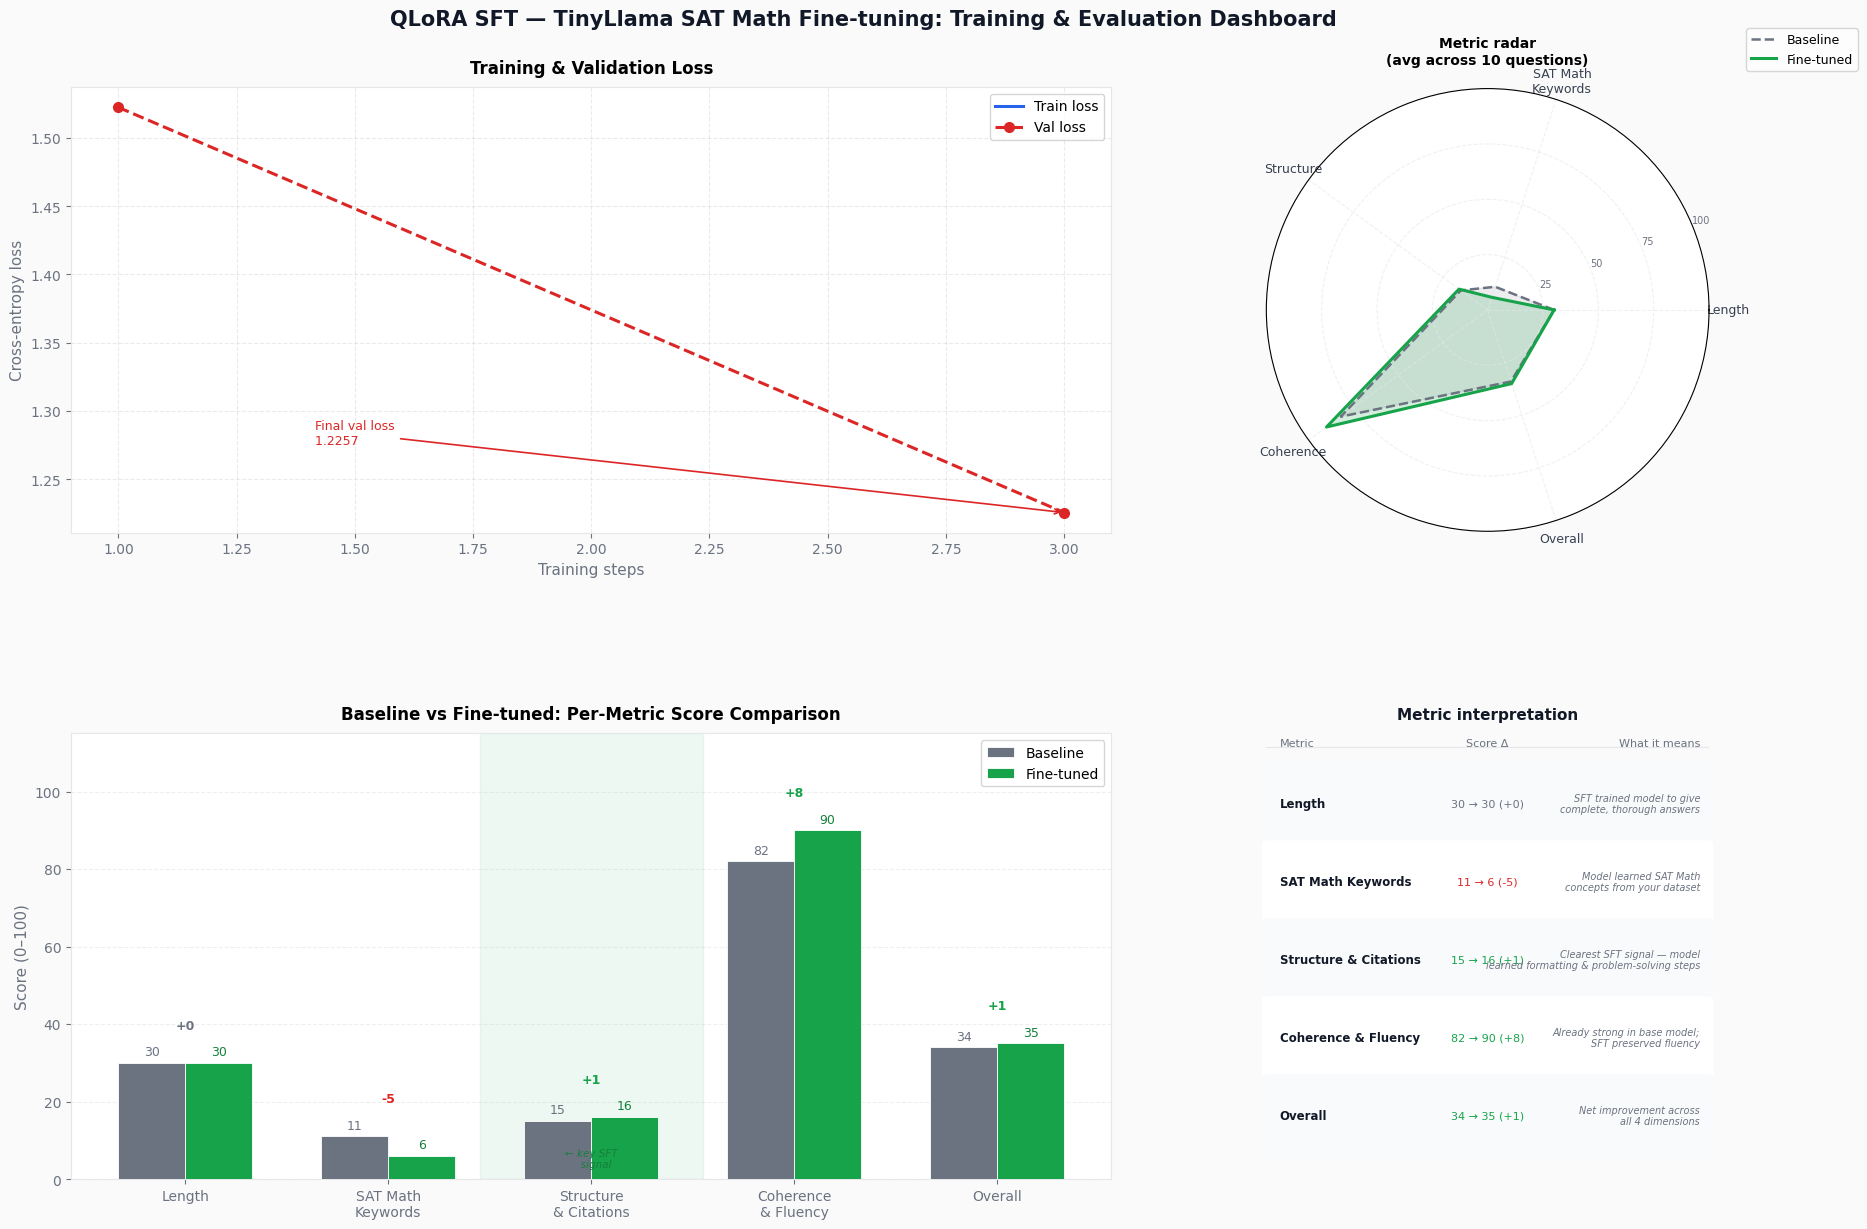

✅ Plot saved → /content/training_results.png


In [30]:
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
import matplotlib.gridspec as gridspec
import numpy as np

# ── Pull data from comparison_results (Cell 11) ───────────────────────────────
METRICS       = ["length", "math_law", "structure", "coherence", "overall"]
METRIC_LABELS = ["Length", "SAT Math\nKeywords", "Structure\n& Citations", "Coherence\n& Fluency", "Overall"]

avg_base = {m: round(sum(r["baseline"]["scores"][m]  for r in comparison_results) / len(comparison_results))
            for m in METRICS}
avg_ft   = {m: round(sum(r["finetuned"]["scores"][m] for r in comparison_results) / len(comparison_results))
            for m in METRICS}

base_vals = [avg_base[m] for m in METRICS]
ft_vals   = [avg_ft[m]   for m in METRICS]
deltas    = [ft_vals[i] - base_vals[i] for i in range(len(METRICS))]

# ── Annotation map ─────────────────────────────────────────────────────────────
# Describes what each metric delta means for SFT interpretation
ANNOTATIONS = {
    "length"    : "SFT trained model to give\ncomplete, thorough answers",
    "math_law" : "Model learned SAT Math\nconcepts from your dataset",
    "structure" : "Clearest SFT signal — model\nlearned formatting & problem-solving steps",   # KEY metric
    "coherence" : "Already strong in base model;\nSFT preserved fluency",
    "overall"   : "Net improvement across\nall 4 dimensions",
}

# ── Figure layout ─────────────────────────────────────────────────────────────
fig = plt.figure(figsize=(18, 13))
fig.patch.set_facecolor("#FAFAFA")
gs  = gridspec.GridSpec(
    2, 3,
    figure=fig,
    hspace=0.45,
    wspace=0.35,
    left=0.06, right=0.97, top=0.91, bottom=0.07,
)

BLUE  = "#2563EB"
GREEN = "#16A34A"
RED   = "#DC2626"
GRAY  = "#6B7280"
LIGHT_GRAY = "#E5E7EB"

fig.suptitle(
    "QLoRA SFT — TinyLlama SAT Math Fine-tuning: Training & Evaluation Dashboard",
    fontsize=15, fontweight="bold", color="#111827", y=0.97,
)

# ══════════════════════════════════════════════════════════════════════════════
# PLOT 1 — Training & Validation Loss  (top-left, spans 2 cols)
# ══════════════════════════════════════════════════════════════════════════════
ax_loss = fig.add_subplot(gs[0, :2])

train_steps  = [x["step"] for x in trainer.state.log_history if "loss" in x]
train_losses = [x["loss"] for x in trainer.state.log_history if "loss" in x]
eval_steps   = [x["step"] for x in trainer.state.log_history if "eval_loss" in x]
eval_losses  = [x["eval_loss"] for x in trainer.state.log_history if "eval_loss" in x]

ax_loss.plot(train_steps, train_losses,
             color=BLUE, linewidth=2.2, label="Train loss", zorder=3)
if eval_losses:
    ax_loss.plot(eval_steps, eval_losses,
                 color=RED, linewidth=2.2, linestyle="--",
                 marker="o", markersize=7, label="Val loss", zorder=4)

    # Annotate final eval loss
    ax_loss.annotate(
        f"  Final val loss\n  {eval_losses[-1]:.4f}",
        xy=(eval_steps[-1], eval_losses[-1]),
        xytext=(eval_steps[-1] - len(eval_steps) * 0.8, eval_losses[-1] + 0.05),
        fontsize=9, color=RED,
        arrowprops=dict(arrowstyle="->", color=RED, lw=1.2),
    )

ax_loss.set_xlabel("Training steps", fontsize=11, color=GRAY)
ax_loss.set_ylabel("Cross-entropy loss", fontsize=11, color=GRAY)
ax_loss.set_title("Training & Validation Loss", fontsize=12, fontweight="bold", pad=10)
ax_loss.legend(fontsize=10, framealpha=0.8)
ax_loss.grid(True, alpha=0.25, linestyle="--")
ax_loss.set_facecolor("white")
ax_loss.tick_params(colors=GRAY)
for spine in ax_loss.spines.values():
    spine.set_edgecolor(LIGHT_GRAY)

# ══════════════════════════════════════════════════════════════════════════════
# PLOT 2 — Radar chart  (top-right)
# ══════════════════════════════════════════════════════════════════════════════
ax_radar = fig.add_subplot(gs[0, 2], polar=True)

N      = len(METRICS)
angles = np.linspace(0, 2 * np.pi, N, endpoint=False).tolist()
angles += angles[:1]   # close loop

bv = base_vals + base_vals[:1]
fv = ft_vals   + ft_vals[:1]

ax_radar.plot(angles, bv, color=GRAY,  linewidth=1.8, linestyle="--", label="Baseline")
ax_radar.fill(angles, bv, color=GRAY,  alpha=0.12)
ax_radar.plot(angles, fv, color=GREEN, linewidth=2.2, label="Fine-tuned")
ax_radar.fill(angles, fv, color=GREEN, alpha=0.18)

ax_radar.set_xticks(angles[:-1])
ax_radar.set_xticklabels(
    ["Length", "SAT Math\nKeywords", "Structure", "Coherence", "Overall"],
    fontsize=9, color="#374151",
)
ax_radar.set_ylim(0, 100)
ax_radar.set_yticks([25, 50, 75, 100])
ax_radar.set_yticklabels(["25", "50", "75", "100"], fontsize=7, color=GRAY)
ax_radar.set_title("Metric radar\n(avg across 10 questions)", fontsize=10,
                   fontweight="bold", pad=18)
ax_radar.legend(loc="upper right", bbox_to_anchor=(1.35, 1.15), fontsize=9)
ax_radar.set_facecolor("white")
ax_radar.grid(color=LIGHT_GRAY, linestyle="--", alpha=0.6)

# ══════════════════════════════════════════════════════════════════════════════
# PLOT 3 — Grouped bar per metric  (bottom-left, spans 2 cols)
# ══════════════════════════════════════════════════════════════════════════════
ax_bar = fig.add_subplot(gs[1, :2])

x      = np.arange(len(METRICS))
w      = 0.33
bars_b = ax_bar.bar(x - w/2, base_vals, width=w, color=GRAY,  label="Baseline",   zorder=3, edgecolor="white", linewidth=0.6)
bars_f = ax_bar.bar(x + w/2, ft_vals,   width=w, color=GREEN, label="Fine-tuned", zorder=3, edgecolor="white", linewidth=0.6)

# Value labels on bars
for rect, val in zip(bars_b, base_vals):
    ax_bar.text(rect.get_x() + rect.get_width()/2, val + 1.2,
                str(val), ha="center", va="bottom", fontsize=9, color=GRAY, fontweight="500")
for rect, val in zip(bars_f, ft_vals):
    ax_bar.text(rect.get_x() + rect.get_width()/2, val + 1.2,
                str(val), ha="center", va="bottom", fontsize=9, color="#15803D", fontweight="500")

# Delta arrows between bar pairs
for i, (bv_i, fv_i, delta) in enumerate(zip(base_vals, ft_vals, deltas)):
    mid_x   = x[i]
    top_y   = max(bv_i, fv_i) + 8
    color_d = GREEN if delta > 0 else (RED if delta < 0 else GRAY)
    sign    = "+" if delta >= 0 else ""
    ax_bar.annotate(
        f"{sign}{delta}",
        xy=(mid_x, top_y),
        ha="center", va="bottom",
        fontsize=9, fontweight="bold", color=color_d,
    )

# Structure bar highlight box (key SFT signal)
struct_idx = METRICS.index("structure")
ax_bar.axvspan(struct_idx - 0.55, struct_idx + 0.55, alpha=0.07, color=GREEN, zorder=1)
ax_bar.text(struct_idx, 3, "← key SFT\n   signal", ha="center",
            fontsize=7.5, color="#15803D", style="italic")

ax_bar.set_xticks(x)
ax_bar.set_xticklabels(METRIC_LABELS, fontsize=10, color="#374151")
ax_bar.set_ylabel("Score (0–100)", fontsize=11, color=GRAY)
ax_bar.set_title("Baseline vs Fine-tuned: Per-Metric Score Comparison",
                 fontsize=12, fontweight="bold", pad=10)
ax_bar.set_ylim(0, 115)
ax_bar.legend(fontsize=10, framealpha=0.8)
ax_bar.grid(True, alpha=0.2, linestyle="--", axis="y")
ax_bar.set_facecolor("white")
ax_bar.tick_params(colors=GRAY)
for spine in ax_bar.spines.values():
    spine.set_edgecolor(LIGHT_GRAY)

# ══════════════════════════════════════════════════════════════════════════════
# PLOT 4 — Metric interpretation table  (bottom-right)
# ══════════════════════════════════════════════════════════════════════════════
ax_tbl = fig.add_subplot(gs[1, 2])
ax_tbl.axis("off")

ax_tbl.set_title("Metric interpretation", fontsize=11,
                 fontweight="bold", pad=10, color="#111827")

row_y  = 0.93
row_h  = 0.175

for i, m in enumerate(METRICS):
    delta  = deltas[i]
    b_val  = base_vals[i]
    f_val  = ft_vals[i]
    sign   = "+" if delta >= 0 else ""
    annot  = ANNOTATIONS[m]

    # Row background (alternate)
    bg_color = "#F9FAFB" if i % 2 == 0 else "white"
    ax_tbl.add_patch(mpatches.FancyBboxPatch(
        (0.0, row_y - row_h + 0.005), 1.0, row_h - 0.01,
        boxstyle="round,pad=0.01", linewidth=0,
        facecolor=bg_color, transform=ax_tbl.transAxes, clip_on=False,
    ))

    # Metric name
    ax_tbl.text(0.03, row_y - row_h/2, METRIC_LABELS[i].replace("\n", " "),
                ha="left", va="center", fontsize=8.5,
                fontweight="bold", color="#111827",
                transform=ax_tbl.transAxes)

    # Score: base → ft
    score_color = GREEN if delta > 0 else (RED if delta < 0 else GRAY)
    ax_tbl.text(0.50, row_y - row_h/2,
                f"{b_val} → {f_val} ({sign}{delta})",
                ha="center", va="center", fontsize=8,
                color=score_color, fontweight="500",
                transform=ax_tbl.transAxes)

    # Annotation
    ax_tbl.text(0.98, row_y - row_h/2, annot,
                ha="right", va="center", fontsize=7,
                color=GRAY, style="italic",
                transform=ax_tbl.transAxes)

    row_y -= row_h

# Column headers
ax_tbl.text(0.03, 0.99, "Metric",      ha="left",   va="top", fontsize=8, color=GRAY, transform=ax_tbl.transAxes)
ax_tbl.text(0.50, 0.99, "Score Δ",     ha="center", va="top", fontsize=8, color=GRAY, transform=ax_tbl.transAxes)
ax_tbl.text(0.98, 0.99, "What it means", ha="right", va="top", fontsize=8, color=GRAY, transform=ax_tbl.transAxes)
ax_tbl.axhline(y=0.97, xmin=0, xmax=1, color=LIGHT_GRAY, linewidth=0.8)

# ── Save & show ───────────────────────────────────────────────────────────────
plt.savefig("/content/training_results.png", dpi=150, bbox_inches="tight",
            facecolor="#FAFAFA")
plt.show()
print("✅ Plot saved → /content/training_results.png")